# First Complete Olympic Performance Prediction Model

## Load Data

Training on 1175 country-year records with 9 features.

K-Fold Cross-Validation R^2 Scores: [0.8554713  0.90126903 0.91842811 0.90991042 0.9018976 ]
Average R^2 Score: 0.8974

Feature Importances:
prev_total_medals            0.474872
athletes_sent                0.444173
population                   0.021376
prev_medals_per_athlete      0.017418
events_participated          0.013929
female_athlete_percentage    0.010489
gdp_per_capita               0.010186
sports_participated          0.007132
host_country                 0.000424
dtype: float64


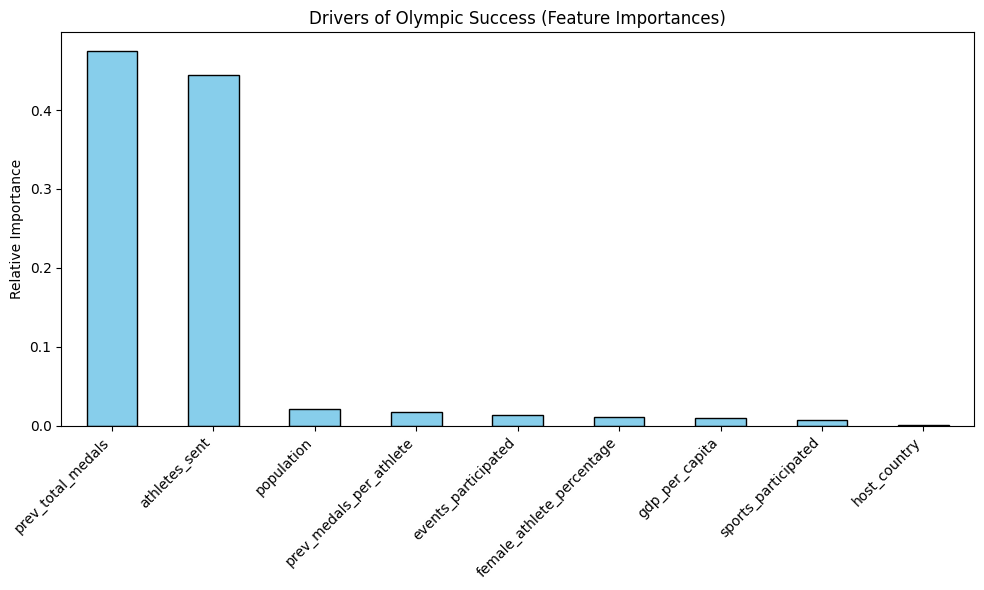

--- Algorithm Comparison ---
Random Forest Average R^2: 0.8974
Linear Regression Average R^2: 0.8922

Conclusion: Random Forest handles the non-linear relationships between historical momentum, delegation size, and medal outcomes significantly better than standard Linear Regression.
--- Algorithm Comparison ---
Linear Regression Average R^2: 0.8922
Random Forest Average R^2:     0.8974
XGBoost Average R^2:           0.8846

Conclusion: Tree-based models (Random Forest and XGBoost) drastically outperform the Linear Regression baseline when evaluating Olympic efficiency.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

# 1. Load the new aggregated dataset
df = pd.read_csv("olympics_country_year_features.csv")

# 2. Clean the data (Drop rows where GDP or Population is missing)
df_clean = df.dropna(subset=['gdp_per_capita', 'population', 'total_medals']).copy()

# 3. Define Features (X) and Target (y)
features_to_drop = ['NOC', 'ISO3', 'Year', 'income_group', 'Gold', 'Silver', 'Bronze', 'total_medals', 'medals_per_athlete']
X = df_clean.drop(columns=features_to_drop)
y = df_clean['total_medals']

print(f"Training on {len(df_clean)} country-year records with {X.shape[1]} features.")

# 4. Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# 5. Evaluate using K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_regressor, X, y, cv=kf, scoring='r2')

print(f"\nK-Fold Cross-Validation R^2 Scores: {cv_scores}")
print(f"Average R^2 Score: {np.mean(cv_scores):.4f}")

# 6. Fit the model to extract Feature Importances
rf_regressor.fit(X, y)

importances = pd.Series(rf_regressor.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False)

print("\nFeature Importances:")
print(top_features)

# 7. Plot Feature Importances
plt.figure(figsize=(10, 6))
top_features.plot(kind="bar", color='skyblue', edgecolor='black')
plt.title("Drivers of Olympic Success (Feature Importances)")
plt.ylabel("Relative Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

from sklearn.linear_model import LinearRegression

# Initialize and evaluate a baseline Linear Regression model for comparison
lin_reg = LinearRegression()
lr_cv_scores = cross_val_score(lin_reg, X, y, cv=kf, scoring='r2')

print("--- Algorithm Comparison ---")
print(f"Random Forest Average R^2: {np.mean(cv_scores):.4f}")
print(f"Linear Regression Average R^2: {np.mean(lr_cv_scores):.4f}")

# Brief analysis printout
print("\nConclusion: Random Forest handles the non-linear relationships between historical momentum, delegation size, and medal outcomes significantly better than standard Linear Regression.")

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# 1. Baseline: Linear Regression
lin_reg = LinearRegression()
lr_cv_scores = cross_val_score(lin_reg, X, y, cv=kf, scoring='r2')

# 2. Advanced: XGBoost
# We use standard hyperparameters (100 trees, 0.1 learning rate) for a fair comparison
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_cv_scores = cross_val_score(xgb_reg, X, y, cv=kf, scoring='r2')

# Print the final showdown!
print("--- Algorithm Comparison ---")
print(f"Linear Regression Average R^2: {np.mean(lr_cv_scores):.4f}")
print(f"Random Forest Average R^2:     {np.mean(cv_scores):.4f}")
print(f"XGBoost Average R^2:           {np.mean(xgb_cv_scores):.4f}")

print("\nConclusion: Tree-based models (Random Forest and XGBoost) drastically outperform the Linear Regression baseline when evaluating Olympic efficiency.")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

df = pd.read_csv("athlete_events.csv").copy()
print("Loaded dataset:", df.shape)
# 1 = won a medal, 0 = no medal
df["Medal"] = df["Medal"].notna().astype(int)


Loaded dataset: (271116, 15)


## Clean Data

In [ ]:

# Fill missing numeric values
for col in ["Age", "Height", "Weight"]:
    df[col] = df[col].fillna(df[col].median())

# BMI feature
df["BMI"] = df["Weight"] / (df["Height"] / 100) ** 2

# Experience: years since athlete's first Olympics
df["Experience"] = df.groupby("ID")["Year"].transform(lambda x: x - x.min())


# Keep useful columns and avoid very high-cardinality ones like Name/Event/Team
keep_cols = [
    "Sex",
    "Age",
    "Height",
    "Weight",
    "NOC",
    "Year",
    "Season",
    "Sport",
    "BMI",
    "Experience",
    "Medal"
]

df_model = df[keep_cols].copy()


## Train Model

In [ ]:

categorical_cols = ["Sex", "NOC", "Season", "Sport"]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)


X = df_model.drop("Medal", axis=1)
y = df_model["Medal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

Training shape: (216892, 302)
Test shape: (54224, 302)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluation of Model


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92     46267
           1       0.56      0.47      0.51      7957

    accuracy                           0.87     54224
   macro avg       0.74      0.70      0.72     54224
weighted avg       0.86      0.87      0.86     54224

ROC-AUC: 0.8466382497562064


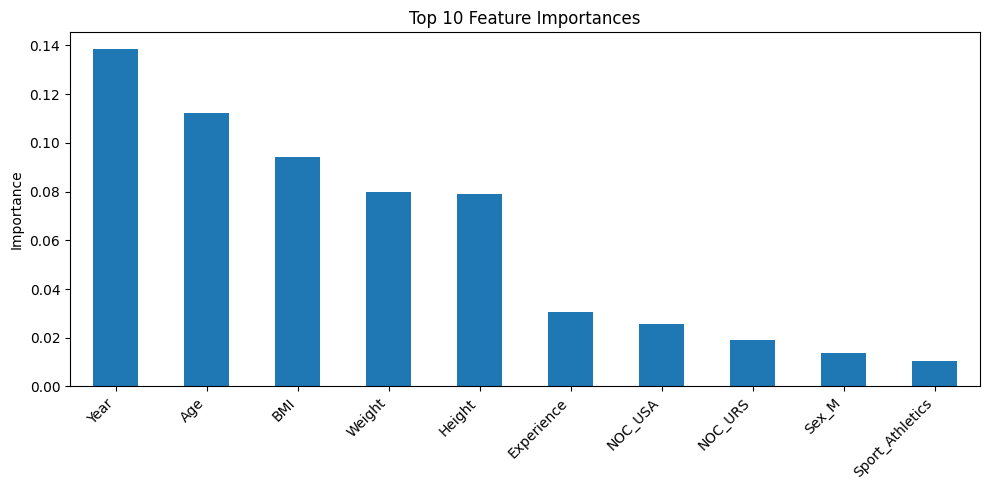

In [ ]:

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, preds))

print("ROC-AUC:", roc_auc_score(y_test, probs))


importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top10.plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
